# Sprint 11 — Visualitzacions amb Python (MySQL + Seaborn + Power BI)

Aquest notebook connecta amb la base de dades del Sprint 4, crea les visualitzacions demanades als Nivells 1 i 2, i prepara els scripts de Python per portar-les a Power BI (Nivell 3).

In [1]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NIVELL 1

## 1. Connexió amb MySQL i càrrega de dades

In [2]:
usuario = "root"
password = quote_plus("TU_CONTRASENYA_AQUI")  # substitueix per la teva contrasenya real; no la deixis mai escrita si comparteixes el notebook
host = "localhost"
puerto = 3306
bd = "sprint_4"

engine = create_engine(
    f"mysql+pymysql://{usuario}:{password}@{host}:{puerto}/{bd}"
)

print("Conexión creada")


Conexión creada


In [3]:
with engine.connect() as conn:
    print("¡Conexión correcta!")

¡Conexión correcta!


In [4]:
df_users = pd.read_sql("SELECT * FROM users", engine)
df_transactions = pd.read_sql("SELECT * FROM transactions", engine)
df_companies = pd.read_sql("SELECT * FROM companies", engine)
df_cards = pd.read_sql("SELECT * FROM credit_cards", engine)
df_products = pd.read_sql("SELECT * FROM products", engine)

df_users.head()

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,Amèrica
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave,Amèrica
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.,Amèrica
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,Amèrica
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.,Amèrica


In [5]:
print(df_users.shape)
print(df_transactions.shape)
print(df_companies.shape)
print(df_cards.shape)
print(df_products.shape)

(5000, 11)
(100000, 10)
(5100, 6)
(5000, 9)
(100, 6)


## 2. Visualitzacions

Per als exercicis que necessiten dades a nivell de client (freqüència de compra, ticket mitjà, despesa total), es crea **un únic DataFrame `clients`** amb les tres mètriques de cop. Així s'evita repetir el mateix `groupby` diverses vegades: es calcula una sola vegada i es reutilitza als exercicis 2, 6 i 7.

In [6]:
clients = (
    df_transactions
    .groupby("user_id")
    .agg(
        freq_compra=("id", "count"),
        ticket_mig=("amount", "mean"),
        despesa_total=("amount", "sum")
    )
    .reset_index()
)

clients.head()

,user_id,freq_compra,ticket_mig,despesa_total
0,1,26,307.978077,8007.43
1,2,30,274.521333,8235.64
2,3,32,283.713125,9078.82
3,4,29,268.504483,7786.63
4,5,38,292.648684,11120.65


### 2.1 Una variable numèrica

Variable: `amount`. Gràfic: histograma, per veure com es reparteixen els imports de les transaccions.

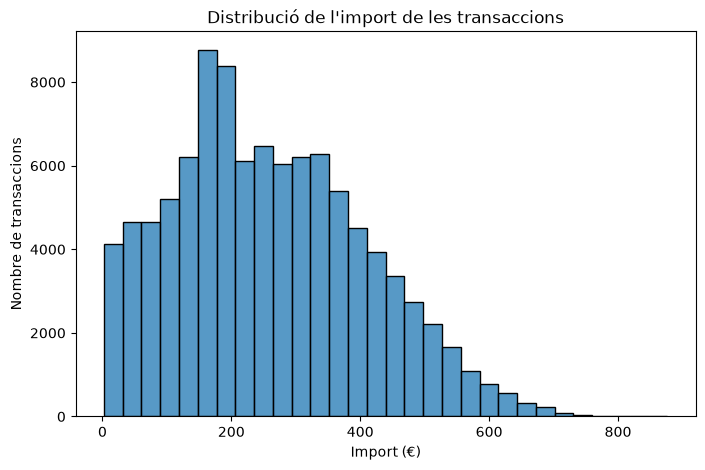

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(data=df_transactions, x="amount", bins=30)

plt.title("Distribució de l'import de les transaccions")
plt.xlabel("Import (€)")
plt.ylabel("Nombre de transaccions")

plt.show()

**Interpretació:** la majoria de les transaccions tenen un import mitjà-baix, amb una cua d'imports més alts que són menys freqüents. No s'observen valors extrems que facin pensar en errors de dades.

### 2.2 Dues variables numèriques

Variables: `freq_compra` i `ticket_mig` (de `clients`). Gràfic: scatterplot, per veure si hi ha relació entre comprar sovint i tenir un ticket mitjà alt.

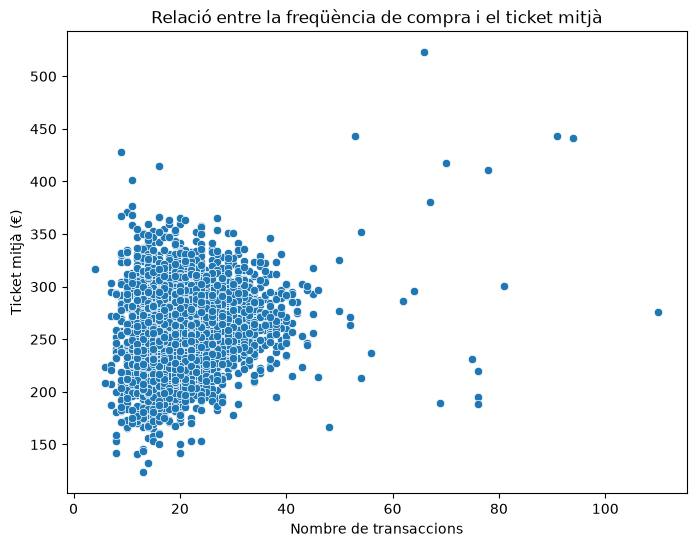

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clients,
    x="freq_compra",
    y="ticket_mig"
)

plt.title("Relació entre la freqüència de compra i el ticket mitjà")
plt.xlabel("Nombre de transaccions")
plt.ylabel("Ticket mitjà (€)")

plt.show()

**Interpretació:** no hi ha una relació clara entre les dues variables; hi ha clients que compren sovint amb tickets baixos i clients que compren poc amb tickets alts. Són comportaments independents.

### 2.3 Una variable categòrica

Variable: `country`. Gràfic: countplot, per comptar quants usuaris hi ha per país.

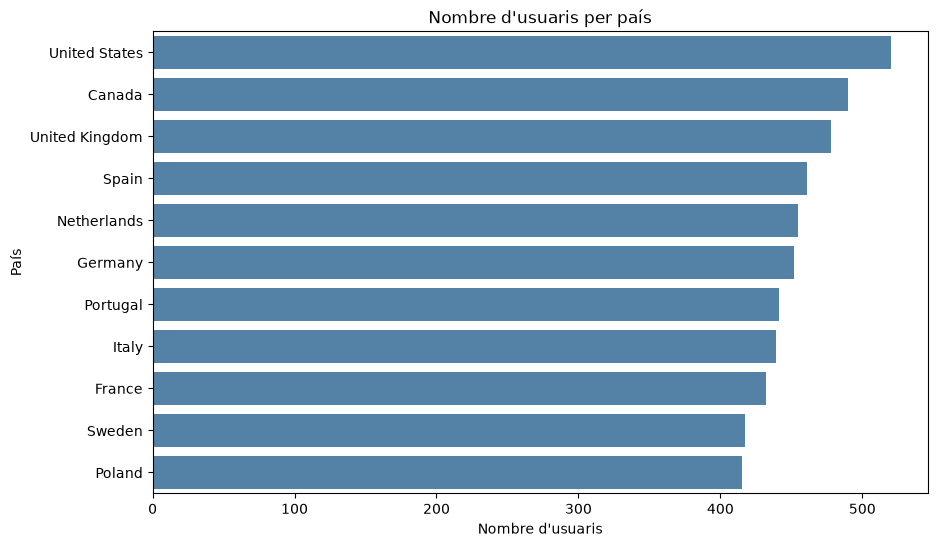

In [9]:
plt.figure(figsize=(10,6))

ordre = df_users["country"].value_counts().index

sns.countplot(
    data=df_users,
    y="country",
    order=ordre,
    color="steelblue"
)

plt.title("Nombre d'usuaris per país")
plt.xlabel("Nombre d'usuaris")
plt.ylabel("País")

plt.show()

**Interpretació:** els Estats Units concentren clarament el major nombre d'usuaris, seguits d'un grup de països europeus amb xifres més repartides entre ells.

### 2.4 Una variable categòrica i una numèrica

Variables: `country` (categòrica) i `amount` sumat per país (numèrica). Cal fer `merge` entre transaccions i usuaris perquè `country` viu a `df_users`. Gràfic: barplot, per comparar el total de vendes entre països.

In [10]:
df = df_transactions.merge(
    df_users,
    left_on="user_id",
    right_on="id",
    how="left"
)

vendes_pais = (
    df.groupby("country")["amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

vendes_pais

,country,amount
0,United States,3024977.71
1,Canada,2584178.24
2,United Kingdom,2478416.85
3,Spain,2336623.33
4,Netherlands,2316227.02
5,Germany,2265471.24
6,Portugal,2250608.19
7,Italy,2238008.35
8,France,2175321.38
9,Poland,2141757.73


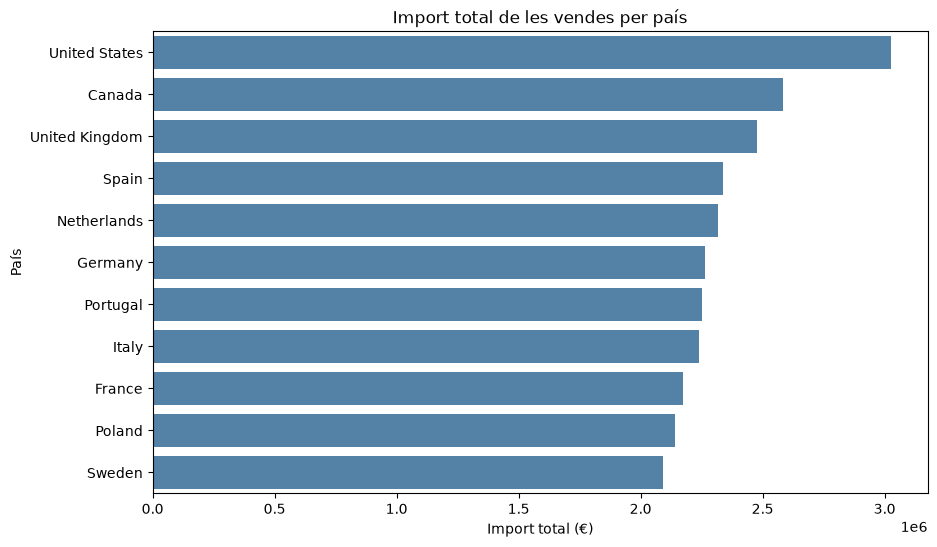

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=vendes_pais,
    x="amount",
    y="country",
    color="steelblue"
)

plt.title("Import total de les vendes per país")
plt.xlabel("Import total (€)")
plt.ylabel("País")

plt.show()

**Interpretació:** els Estats Units també lideren en import total de vendes, coherent amb ser el país amb més usuaris. La resta de països europeus mostren imports totals força similars entre ells.

### 2.5 Dues variables categòriques

Variables: `country` i `region` (ja disponibles a `df` fusionat). Gràfic: heatmap sobre una taula de contingència (`crosstab`), per veure com es combinen les categories.

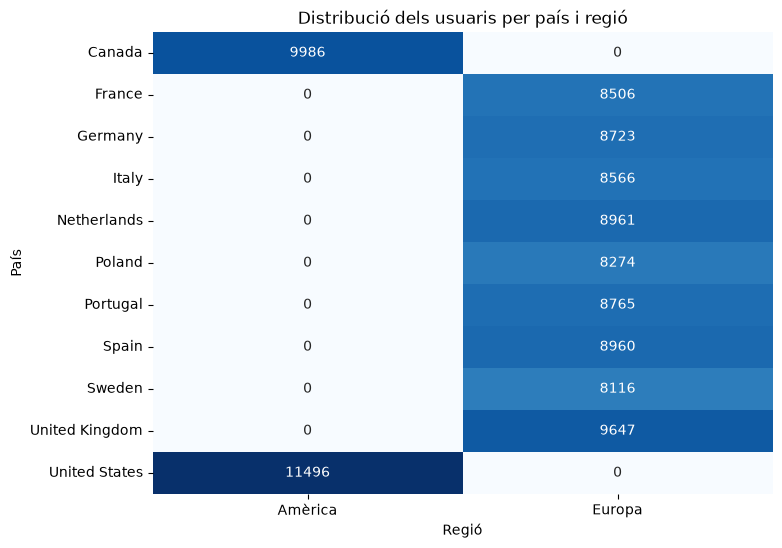

In [12]:
taula = pd.crosstab(df["country"], df["region"])

plt.figure(figsize=(8,6))

sns.heatmap(
    taula,
    cmap="Blues",
    annot=True,
    fmt="d",
    cbar=False
)

plt.title("Distribució dels usuaris per país i regió")
plt.xlabel("Regió")
plt.ylabel("País")

plt.show()

**Interpretació:** cada país apareix associat a una única regió, la qual cosa confirma que la relació país–regió és fixa (jeràrquica) i no una correlació estadística a interpretar.

### 2.6 Tres variables combinades

Variables: `freq_compra`, `ticket_mig` i `despesa_total` (de `clients`, ja calculat). Gràfic: scatterplot amb mida de punt (bubble chart), la manera més senzilla d'afegir una tercera variable a un scatter.

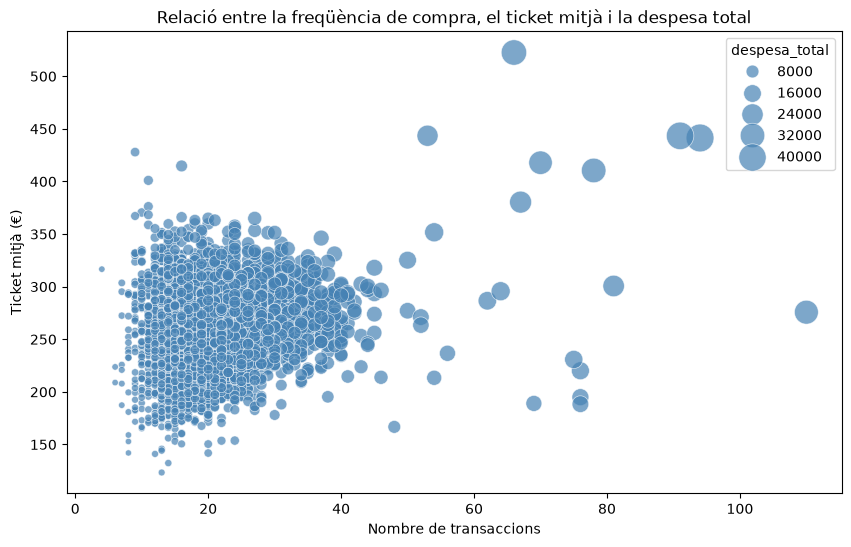

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=clients,
    x="freq_compra",
    y="ticket_mig",
    size="despesa_total",
    sizes=(20,400),
    alpha=0.7,
    color="steelblue"
)

plt.title("Relació entre la freqüència de compra, el ticket mitjà i la despesa total")
plt.xlabel("Nombre de transaccions")
plt.ylabel("Ticket mitjà (€)")

plt.show()

**Interpretació:** els clients amb més despesa total (punts més grans) hi arriben sobretot comprant sovint, no per tenir un ticket mitjà alt.

### 2.7 Pairplot

Variables: les mateixes tres de `clients`. Gràfic: pairplot, per veure totes les combinacions de parelles de cop, més histogrames a la diagonal.

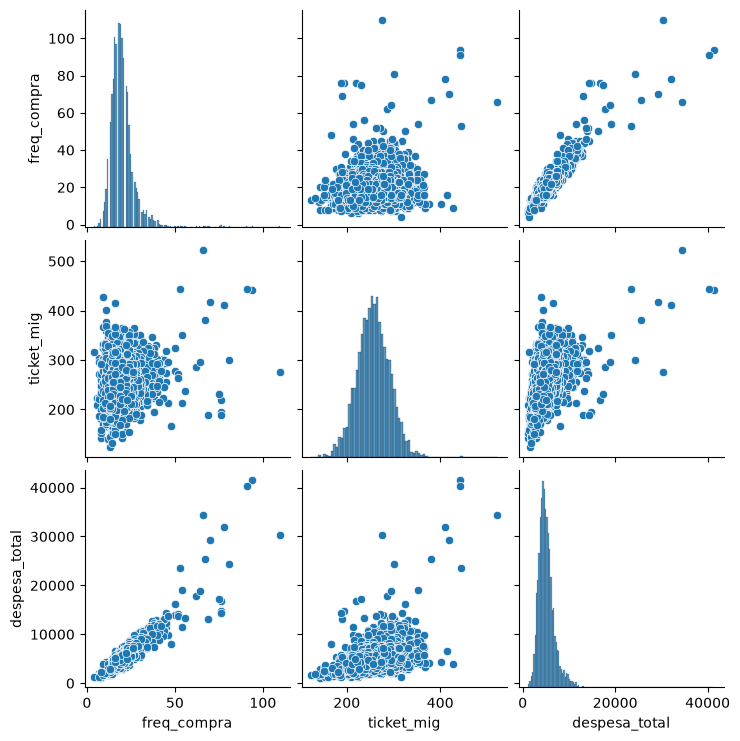

In [14]:
clients_plot = clients.rename(columns={
    "freq_compra": "freq_compra (num. transaccions)",
    "ticket_mig": "ticket_mig (€)",
    "despesa_total": "despesa_total (€)"
})

sns.pairplot(
    clients_plot[["freq_compra (num. transaccions)", "ticket_mig (€)", "despesa_total (€)"]]
)

plt.show()


**Interpretació:** es confirma el patró vist anteriorment: `despesa_total` creix clarament amb `freq_compra`, mentre que `ticket_mig` no mostra relació forta amb cap de les altres dues.

# NIVELL 2

## 1. Correlació entre variables

Variables: `freq_compra`, `ticket_mig`, `despesa_total` (de `clients`, sense crear cap DataFrame nou). Gràfic: heatmap de correlació, per veure numèricament i visualment com es relacionen entre elles.

**Comprovació prèvia:** `.corr()` fa servir per defecte el coeficient de Pearson, que assumeix que les variables segueixen una distribució normal. Abans de llegir el heatmap, fem un cop d'ull ràpid a la forma de les tres variables.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, ["freq_compra", "ticket_mig", "despesa_total"]):
    sns.histplot(clients[col], ax=ax, bins=20)
    ax.set_title(col)

plt.tight_layout()
plt.show()


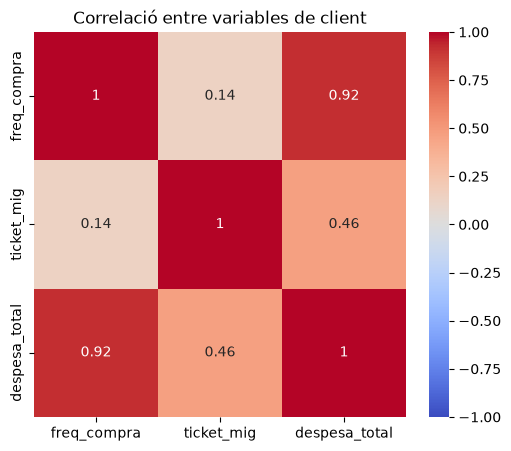

In [15]:
correlacio = clients[["freq_compra", "ticket_mig", "despesa_total"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    correlacio,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlació entre variables de client")

plt.show()

**Interpretació:** `despesa_total` correlaciona fort i de manera positiva amb `freq_compra` (comprar més sovint és el que més explica gastar més en total). `ticket_mig` gairebé no correlaciona amb cap de les altres dues; és independent. Cal tenir en compte que aquest coeficient assumeix normalitat a les variables; als histogrames anteriors es veu que `despesa_total` no té una forma clarament normal, així que aquest valor de correlació s'ha de llegir amb cautela.


## 2. Jointplot

Variables: `freq_compra` i `ticket_mig` (les mateixes de l'apartat 2.2 del Nivell 1). Gràfic: jointplot, que combina el scatterplot central amb un histograma de cada variable als marges.

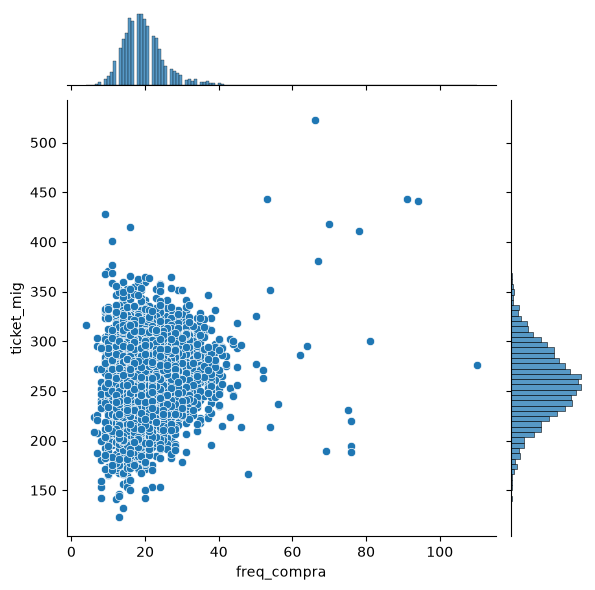

In [16]:
sns.jointplot(
    data=clients,
    x="freq_compra",
    y="ticket_mig",
    kind="scatter"
)

plt.show()

**Interpretació:** el núvol de punts confirma que no hi ha relació clara entre les dues variables. Els histogrames dels marges mostren que `freq_compra` es reparteix de manera bastant uniforme, mentre que `ticket_mig` es concentra més al voltant d'un valor central.

# NIVELL 3

## Transferir les visualitzacions del Nivell 1 a Power BI

Idea clau: a Power BI **no es tornen a crear DataFrames nous**. La càrrega de dades (amb els `groupby`/`merge` necessaris) es fa una única vegada, en el moment d'importar les taules al model. Un cop les taules ja hi són, cada visual de Python de Power BI rep automàticament un DataFrame anomenat `dataset` amb només les columnes que hi arrossegues, i tu només hi enganxes el codi de seaborn de sempre, canviant el nom del DataFrame.

**Columna identificadora única** (per evitar que Power BI elimini duplicats): `df_transactions` ja té `id` (UUID únic per transacció); `clients` té `user_id` (únic, ve d'un `groupby`). No cal afegir res nou, ja es compleix el requisit.

### 3.1 Càrrega de taules al model (Obtenir dades → Script de Python)

Aquest script es fa servir **una sola vegada**, al moment de connectar Power BI a les dades. Genera les taules `df_users`, `df_transactions` i `clients` que després s'utilitzaran als visuals.

In [17]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

usuario = "root"
password = quote_plus("TU_CONTRASENYA_AQUI")  # substitueix per la teva contrasenya real abans d'executar-ho a Power BI
host = "localhost"
puerto = 3306
bd = "sprint_4"

engine = create_engine(
    f"mysql+pymysql://{usuario}:{password}@{host}:{puerto}/{bd}"
)

df_users = pd.read_sql("SELECT * FROM users", engine)
df_transactions = pd.read_sql("SELECT * FROM transactions", engine)

clients = (
    df_transactions
    .groupby("user_id")
    .agg(
        freq_compra=("id", "count"),
        ticket_mig=("amount", "mean"),
        despesa_total=("amount", "sum")
    )
    .reset_index()
)


### 3.2 Scripts per a cada visual de Python dins de Power BI

Per a cada gràfic, s'afegeix un visual de Python, s'hi arrosseguen les columnes necessàries (que Power BI converteix en `dataset`), i s'hi enganxa el codi corresponent.

**Visual 1 — Una variable numèrica.** Columnes arrossegades: `amount`.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=dataset, x="amount", bins=30)
plt.title("Distribució de l'import de les transaccions")
plt.show()

NameError: name 'dataset' is not defined

**Visual 2 — Dues variables numèriques.** Columnes arrossegades: `freq_compra`, `ticket_mig` (de la taula `clients`).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=dataset, x="freq_compra", y="ticket_mig")
plt.title("Relació entre la freqüència de compra i el ticket mitjà")
plt.show()

**Visual 3 — Una variable categòrica.** Columnes arrossegades: `country`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ordre = dataset["country"].value_counts().index
sns.countplot(data=dataset, y="country", order=ordre, color="steelblue")
plt.title("Nombre d'usuaris per país")
plt.show()

**Visual 4 — Categòrica + numèrica.** Columnes arrossegades: `country`, `amount`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

vendes_pais = (
    dataset.groupby("country")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=vendes_pais, x="amount", y="country", color="steelblue")
plt.title("Import total de les vendes per país")
plt.show()

**Visual 5 — Dues variables categòriques.** Columnes arrossegades: `country`, `region`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

taula = pd.crosstab(dataset["country"], dataset["region"])
sns.heatmap(taula, cmap="Blues", annot=True, fmt="d", cbar=False)
plt.title("Distribució dels usuaris per país i regió")
plt.show()

**Visual 6 — Tres variables combinades.** Columnes arrossegades: `freq_compra`, `ticket_mig`, `despesa_total` (de `clients`).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=dataset,
    x="freq_compra",
    y="ticket_mig",
    size="despesa_total",
    sizes=(20,400),
    alpha=0.7,
    color="steelblue"
)
plt.title("Relació entre freqüència, ticket mitjà i despesa total")
plt.show()

**Visual 7 — Pairplot.** Columnes arrossegades: `freq_compra`, `ticket_mig`, `despesa_total`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dataset_plot = dataset.rename(columns={
    "freq_compra": "freq_compra (num. transaccions)",
    "ticket_mig": "ticket_mig (€)",
    "despesa_total": "despesa_total (€)"
})

sns.pairplot(dataset_plot[["freq_compra (num. transaccions)", "ticket_mig (€)", "despesa_total (€)"]])
plt.show()


In [19]:
import sys
print(sys.executable)

C:\Users\a-iba\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
